In [ ]:
!unzip "/content/drive/MyDrive/digital_knee_x-ray_ds.zip"

Archive:  /content/drive/MyDrive/digital_knee_x-ray_ds.zip
  inflating: MedicalExpert-I/0Normal/NormalG0 (1).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (10).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (100).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (101).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (102).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (103).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (104).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (105).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (106).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (107).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (108).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (109).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (11).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (110).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (111).png  
  inflating: MedicalExpert-I/0Normal/NormalG0 (112).png  
  inflating: Medi

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import os
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.image import rgb_to_grayscale


In [ ]:
import numpy as np
import pandas as pd
import os
import cv2
import random
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# TensorFlow & Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, Flatten,
    Conv2D, MaxPooling2D, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.utils import to_categorical, load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler

# Sklearn
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [ ]:
for d in os.listdir("/content/MedicalExpert-I"):
    print(d, len(os.listdir("/content/MedicalExpert-I/" + d)))

for d in os.listdir("/content/MedicalExpert-II"):
    print(d, len(os.listdir("/content/MedicalExpert-II/" + d)))

3Moderate 221
4Severe 206
1Doubtful 477
0Normal 514
2Mild 232
3Moderate 221
4Severe 206
1Doubtful 488
0Normal 503
2Mild 232


In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.utils import shuffle
import random
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPooling2D,BatchNormalization,Dropout,Flatten
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam

In [ ]:
def read_data(path,image_size,classes):

    X=[]
    y=[]

    for label in os.listdir(path):

        for img_name in os.listdir(os.path.join(path,label)):

            img=cv2.imread(os.path.join(path,label,img_name))
            img=cv2.resize(img,(image_size,image_size))
            img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

            X.append(img)
            y.append(classes[label])

    return np.array(X),np.array(y)

In [ ]:
knee2_classes = {'0Normal': 0, '1Doubtful' : 1, '2Mild' : 2, '3Moderate' : 3,'4Severe' : 4}
x_traindig_knee,y_traindig_knee = read_data('/content/MedicalExpert-I', 200, knee2_classes)
x_testdig_knee,y_testdig_knee = read_data('/content/MedicalExpert-II', 200, knee2_classes)
x_traindig_knee,y_traindig_knee = shuffle(x_traindig_knee,y_traindig_knee ,random_state = 42)
x_testdig_knee,y_testdig_knee = shuffle(x_testdig_knee,y_testdig_knee,random_state = 42)

In [ ]:
x_knee = np.concatenate((x_traindig_knee,x_testdig_knee))
x_knee.shape

(3300, 200, 200, 3)

In [ ]:
y_knee = np.concatenate((y_traindig_knee,y_testdig_knee))
y_knee.shape

(3300,)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x_knee,y_knee,test_size = 0.25,random_state = 42)

In [ ]:
print(x_train.max(),x_train.min())
print(x_test.max(),x_test.min())
x_train = x_train / 255
x_test = x_test / 255
print(x_train.max(),x_train.min())
print(x_test.max(),x_test.min())
y_train

255 0
255 0
1.0 0.0
1.0 0.0


array([2, 3, 1, ..., 0, 1, 4])

In [ ]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [ ]:
model = Sequential([Conv2D(64, (3, 3), activation='relu', input_shape=(200, 200, 3)),
                   MaxPooling2D((2, 2)), Conv2D(128, (3, 3), activation='relu'), MaxPooling2D((2, 2)),
                   Conv2D(256, (3, 3), activation='relu'), MaxPooling2D((2, 2)), Conv2D(512, (3, 3), activation='relu'),
                   MaxPooling2D((2, 2)), Flatten(), Dense(256,activation = 'relu'), Dropout(0.5), Dense(128, activation='relu'),
                   Dense(64, activation='relu'), Dropout(0.5), Dense(32, activation='relu'), Dense(5, activation='softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(x = x_train,y = y_train,epochs =50 ,validation_data = (x_test,y_test), callbacks=[early_stopping])

Epoch 1/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 39s 303ms/step - accuracy: 0.2824 - loss: 1.5843 - val_accuracy: 0.3042 - val_loss: 1.5566
Epoch 2/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 124ms/step - accuracy: 0.3014 - loss: 1.5525 - val_accuracy: 0.3285 - val_loss: 1.5259
Epoch 3/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 123ms/step - accuracy: 0.3180 - loss: 1.5363 - val_accuracy: 0.3297 - val_loss: 1.5172
Epoch 4/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - accuracy: 0.3220 - loss: 1.5245 - val_accuracy: 0.3467 - val_loss: 1.5031
Epoch 5/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 126ms/step - accuracy: 0.3301 - loss: 1.5258 - val_accuracy: 0.3236 - val_loss: 1.5158
Epoch 6/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 129ms/step - accuracy: 0.3374 - loss: 1.5098 - val_accuracy: 0.3539 - val_loss: 1.4879
Epoch 7/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 10s 130ms/step - accuracy: 0.3289 - loss: 1.4991 - val_accuracy: 0.3600 - val_loss: 1.4951
Epoch 8/50
78/78 ━━━━━━━━━━━━━━━━━━━━ 11s 135ms/step - accuracy: 0.3406 - loss: 1.4921 - val_accu

In [ ]:
model.save("knee_x-ray_cnn_model.h5")

26/26 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step


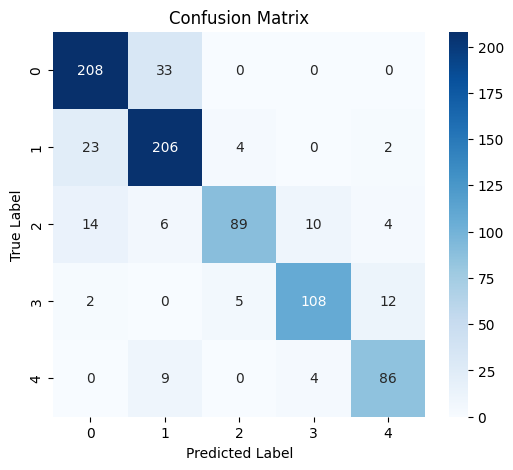

              precision    recall  f1-score   support

           0     0.8421    0.8631    0.8525       241
           1     0.8110    0.8766    0.8425       235
           2     0.9082    0.7236    0.8054       123
           3     0.8852    0.8504    0.8675       127
           4     0.8269    0.8687    0.8473        99

    accuracy                         0.8448       825
   macro avg     0.8547    0.8365    0.8430       825
weighted avg     0.8479    0.8448    0.8443       825



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
# Assuming y_test is one-hot and x_test is your test set
# 1. Get predicted probabilities and class labels
y_pred_proba = model.predict(x_test)                # shape (n_samples, 5)
y_pred = np.argmax(y_pred_proba, axis=1)             # shape (n_samples,)
y_true = np.argmax(y_test, axis=1)                   # shape (n_samples,)
n_classes = y_test.shape[1]

# 2. Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot as heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(n_classes),
            yticklabels=range(n_classes))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 4. (Optional) Print classification report
print(classification_report(y_true, y_pred, digits=4))

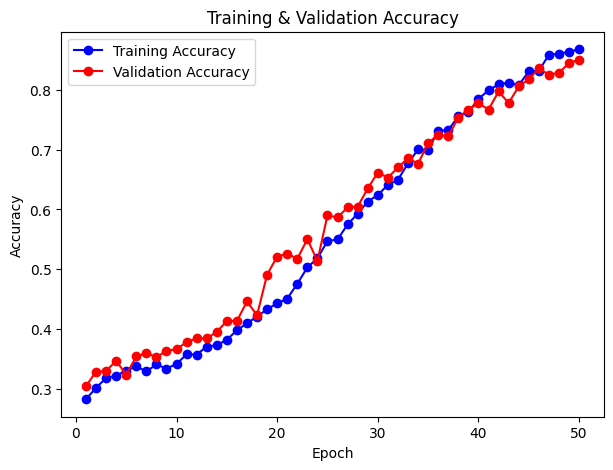

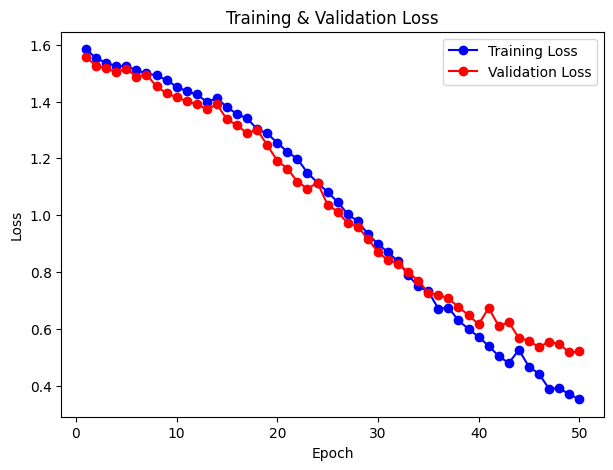

In [ ]:
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs   = range(1, len(acc) + 1)

# 2. Plot accuracy
plt.figure(figsize=(7,5))
plt.plot(epochs, acc,    'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc,'ro-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# 3. Plot loss
plt.figure(figsize=(7,5))
plt.plot(epochs, loss,    'bo-', label='Training Loss')
plt.plot(epochs, val_loss,'ro-', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


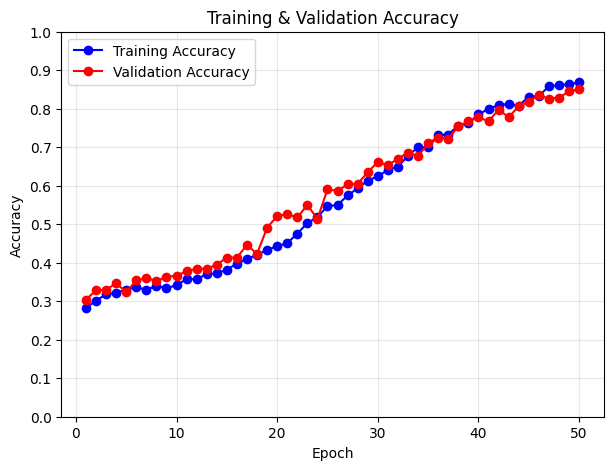

In [ ]:
# 1. Extract metrics from history
acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
epochs   = range(1, len(acc) + 1)

# 2. Plot Training & Validation Accuracy over full 0–1 range
plt.figure(figsize=(7,5))
plt.plot(epochs, acc,     'bo-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0, 1.0)              # force y-axis from 0 to 1
plt.yticks(np.linspace(0, 1, 11))  # ticks at every 0.1 step
plt.legend()
plt.grid(alpha=0.3)
plt.show()

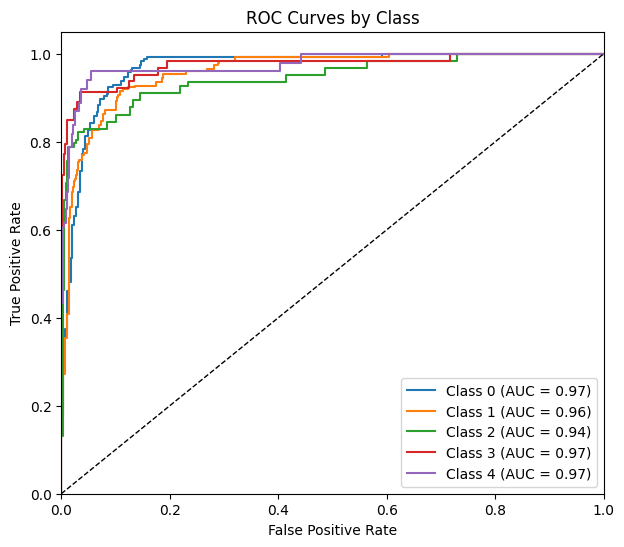

In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 2. Plot all ROC curves
plt.figure(figsize=(7,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i],
             label=f'Class {i} (AUC = {roc_auc[i]:.2f})')
plt.plot([0,1], [0,1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves by Class')
plt.legend(loc='lower right')
plt.show()